<a href="https://colab.research.google.com/github/Nikhilesh-Nanda/Titanic-Survival-Prediction/blob/main/TITANIC_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GET A TASTE OF DATASET

In [ ]:
import pandas as pd

my_data = pd.read_csv("/content/train.csv")

display(my_data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
my_data.shape

(891, 12)

In [ ]:
my_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


No of passengers with no cabin assigned in different classes

In [ ]:
my_data[my_data['Cabin'].isna()].Pclass.value_counts()

,count
Pclass,
3,479
2,168
1,40


**CONVERT MALE AND FEMALE TO 0 OR 1 FOR EASE**

In [ ]:
mapping2 = {"male" : 0, "female" : 1}
my_data['Sex'] = my_data['Sex'].map(mapping2)


In [ ]:
my_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C


**CHECK WHERE THE AGE OF PASSENGERS ARE NOT MENTIONED**

In [ ]:
my_data.Age.isna().value_counts()

,count
Age,
False,714
True,177


**REPLACING ALL THE NAN VALUES WITH THE MEAN**

In [ ]:
mean_age = my_data['Age'].mean()
my_data.loc[my_data['Age'].isna(), 'Age'] = mean_age

**WE CAN OBSERVE THAT ALL NAN VALUES ARE REPLACED**

In [ ]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


**EXAMINE THE ONLY PASSENGER WHO DIDN'T PAY THE FARE**

In [ ]:
my_data.loc[my_data['Fare'].isna(),'Fare'] = 35.627188

display(my_data[my_data['Fare'] == 35.627188])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [ ]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


# **Read Gender Submission**

In [ ]:
import pandas as pd

mine_data = pd.read_csv('/content/gender_submission.csv')

display(mine_data)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


**CHECK THE NUMBER OF SURVIVED AND NOT SURVIVED**

In [ ]:
mine_data['Survived'].value_counts()

,count
Survived,
0,266
1,152


# **CONVERT THE VALUES TO FLOOR TYPE**

**AGE**

In [ ]:
from math import floor
from sklearn.metrics import mean_squared_error,mean_absolute_error

def fun(val):
  return floor(val)
x = my_data['Age'].map(fun)

print(mean_absolute_error(my_data['Age'],x)*100)

my_data['Age'] = x

15.478543605994519


**FARE**

In [ ]:
from math import floor,ceil
from sklearn.metrics import mean_squared_error,mean_absolute_error

def fun(val):
  return ceil(val)
x = my_data['Fare'].map(fun)

print(mean_absolute_error(my_data['Fare'],x)*100)

# my_data['Age'] = x

40.07303030303028


We wouldn't convert or change the values as it would create a significant error

In [ ]:
my_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,NaN,S


# Filtering the age data into different categories

In [ ]:
my_data.Age.describe()

,Age
count,891.000000
mean,29.544332
std,13.013778
min,0.000000
25%,22.000000
50%,29.000000
75%,35.000000
max,80.000000


# Distribution Of Different People On Age Groups

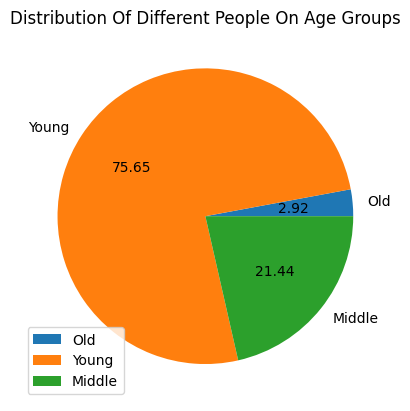

In [ ]:
import matplotlib.pyplot as plt

old = my_data[my_data['Age'] >= 60]
middle = my_data[(my_data['Age'] > 35) & (my_data['Age'] < 60)]
young = my_data[my_data['Age'] <= 35]

labels = ["Old","Young","Middle"]
values_to_plot = [len(old),len(young),len(middle)]

plot = plt.pie(values_to_plot,labels=labels,autopct="%0.2f")

plt.title("Distribution Of Different People On Age Groups")
plt.legend()
plt.show()

In [ ]:
emb_map = {'S':0,'C':1,'Q':2}

my_data['Embarked'] = my_data['Embarked'].map(emb_map)

display(my_data)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,NaN,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,C85,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,NaN,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,C123,0.0
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27,0,0,211536,13.0000,NaN,0.0
887,888,1,1,"Graham, Miss. Margaret Edith",1,19,0,0,112053,30.0000,B42,0.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29,1,2,W./C. 6607,23.4500,NaN,0.0
889,890,1,1,"Behr, Mr. Karl Howell",0,26,0,0,111369,30.0000,C148,1.0


**Distribution Of Poeple Survived According To Passenger Class**

In [ ]:
survived_and_class = my_data[['Survived','Pclass']]

display(survived_and_class)

,Survived,Pclass
0,0,3
1,1,1
2,1,3
3,1,1
4,0,3
...,...,...
886,0,2
887,1,1
888,0,3
889,1,1


# Distribution Of People Going To 3 Cities

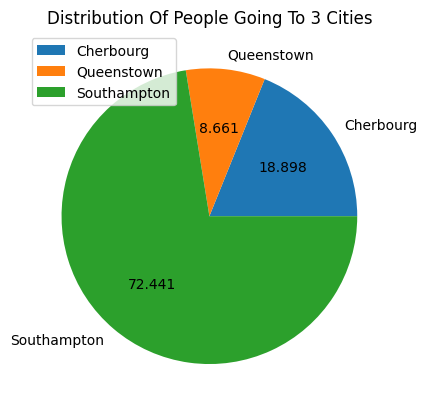

In [ ]:
labels = ['Cherbourg', 'Queenstown', 'Southampton']

unique_counts = my_data.Embarked.value_counts()
count_southAmp = unique_counts[0]
count_Cher = unique_counts[1]
count_Queen = unique_counts[2]

val_array = [count_Cher,count_Queen,count_southAmp]

plt.pie(val_array,labels = labels,autopct = "%0.3f")

plt.title("Distribution Of People Going To 3 Cities")
plt.legend()
plt.show()

# Distribution of people in different classes(first,second,third)

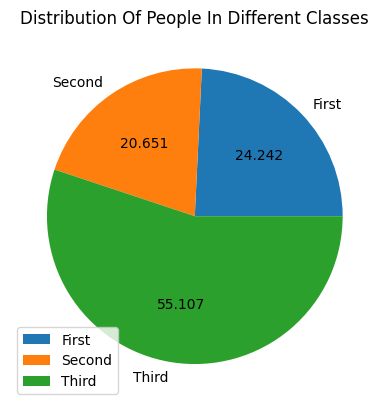

In [ ]:
labels = ['First', 'Second', 'Third']

unique_counts = my_data.Pclass.value_counts()
count_ThirdC = unique_counts[3] # Corrected from unique_counts[0]
count_SecondC = unique_counts[2]
count_FirstC = unique_counts[1]

val_array = [count_FirstC,count_SecondC,count_ThirdC]

plt.pie(val_array,labels = labels,autopct = "%0.3f")

plt.title("Distribution Of People In Different Classes")
plt.legend()
plt.show()

In [ ]:
def fun(val):
  if(val >= 60) : return "Old"
  elif((val > 35) and (val < 60)) : return "Middle"
  elif(val <= 35) : return "Young"
my_data['AgeGroup'] = my_data['Age'].map(fun)

In [ ]:
def fun(val):
  if(val == "Old") : return "O"
  elif(val == "Middle") : return "M"
  elif(val == "Young") : return "Y"
my_data['AgeGroup'] = my_data['AgeGroup'].map(fun)

In [ ]:
my_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,NaN,0.0,Y
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,C85,1.0,M
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,NaN,0.0,Y
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,C123,0.0,Y
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,NaN,0.0,Y


# **REMOVING UNECESSARY COLUMNS**

In [ ]:
y = my_data.drop(columns={'Ticket','Embarked', 'Cabin', 'Name', 'PassengerId'}) # Dropping 'Ticket', 'Embarked', 'Cabin', 'Name', and 'PassengerId' from y temporarily as it's just an intermediate display. Real feature selection happens below.
display(y.head(5))

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,AgeGroup
0,0,3,0,22,1,0,7.2500,Y
1,1,1,1,38,1,0,71.2833,M
2,1,3,1,26,0,0,7.9250,Y
3,1,1,1,35,1,0,53.1000,Y
4,0,3,0,35,0,0,8.0500,Y


In [ ]:
my_data.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
555,556,0,1,"Wright, Mr. George",0,62,0,0,113807,26.5500,NaN,0.0,O
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",1,48,1,0,11755,39.6000,A16,1.0,M
643,644,1,3,"Foo, Mr. Choong",0,29,0,0,1601,56.4958,NaN,0.0,Y
787,788,0,3,"Rice, Master. George Hugh",0,8,4,1,382652,29.1250,NaN,2.0,Y
539,540,1,1,"Frolicher, Miss. Hedwig Margaritha",1,22,0,2,13568,49.5000,B39,1.0,Y
150,151,0,2,"Bateman, Rev. Robert James",0,51,0,0,S.O.P. 1166,12.5250,NaN,0.0,M
749,750,0,3,"Connaghton, Mr. Michael",0,31,0,0,335097,7.7500,NaN,2.0,Y
758,759,0,3,"Theobald, Mr. Thomas Leonard",0,34,0,0,363294,8.0500,NaN,0.0,Y
335,336,0,3,"Denkoff, Mr. Mitto",0,29,0,0,349225,7.8958,NaN,0.0,Y
877,878,0,3,"Petroff, Mr. Nedelio",0,19,0,0,349212,7.8958,NaN,0.0,Y


In [ ]:
# Drop the 'Ticket' and 'Cabin' columns due to complexity and high number of missing values respectively.
my_data = my_data.drop(columns=['Ticket', 'Cabin', 'Name', 'PassengerId'])

# Fill missing 'Embarked' values with the most frequent value (mode)
mode_embarked = my_data['Embarked'].mode()[0]
my_data['Embarked'] = my_data['Embarked'].fillna(mode_embarked)

display(my_data.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
0,0,3,0,22,1,0,7.2500,0.0,Y
1,1,1,1,38,1,0,71.2833,1.0,M
2,1,3,1,26,0,0,7.9250,0.0,Y
3,1,1,1,35,1,0,53.1000,0.0,Y
4,0,3,0,35,0,0,8.0500,0.0,Y


In [ ]:
# The 'Ticket' column was dropped in the previous step.
# We can now check the info to confirm missing values are handled and columns are dropped.
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    float64
 8   AgeGroup  891 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 62.8+ KB


#Converting the embarked into integers

# Converting the age group into integers

In [ ]:
age_group_map = {'M' : 2,'O':3,'Y':1}

my_data['AgeGroup'] = my_data['AgeGroup'].map(age_group_map)

display(my_data)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
0,0,3,0,22,1,0,7.2500,0.0,1
1,1,1,1,38,1,0,71.2833,1.0,2
2,1,3,1,26,0,0,7.9250,0.0,1
3,1,1,1,35,1,0,53.1000,0.0,1
4,0,3,0,35,0,0,8.0500,0.0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27,0,0,13.0000,0.0,1
887,1,1,1,19,0,0,30.0000,0.0,1
888,0,3,1,29,1,2,23.4500,0.0,1
889,1,1,0,26,0,0,30.0000,1.0,1


# **READ TESTING DATA**

In [ ]:
import pandas as pd

test_Data = pd.read_csv('/content/test.csv')

display(test_Data)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


#**Making the model**

**First things first, we first need to update the test data columns so that it matches the original or training data**

In [ ]:
test_Data['Sex'] = my_data['Sex']
test_Data['Ticket'] = my_data['Ticket']
test_Data['Embarked'] = my_data['Embarked']
test_Data['AgeGroup'] = my_data['AgeGroup']

KeyError: 'Ticket'

In [ ]:
my_data['familySize'] = my_data['SibSp'] + my_data['Parch']

my_data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,familySize
0,0,3,0,22,1,0,7.2500,0.0,1,1
1,1,1,1,38,1,0,71.2833,1.0,2,1
2,1,3,1,26,0,0,7.9250,0.0,1,0
3,1,1,1,35,1,0,53.1000,0.0,1,1
4,0,3,0,35,0,0,8.0500,0.0,1,0
5,0,3,0,29,0,0,8.4583,2.0,1,0
6,0,1,0,54,0,0,51.8625,0.0,2,0
7,0,3,0,2,3,1,21.0750,0.0,1,4
8,1,3,1,27,0,2,11.1333,0.0,1,2
9,1,2,1,14,1,0,30.0708,1.0,1,1


In [ ]:
test_Data['familySize'] = test_Data['SibSp'] + test_Data['Parch']

test_Data.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,familySize
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",1,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,3101298,12.2875,NaN,S,2
5,897,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,S,0
6,898,3,"Connolly, Miss. Kate",0,30.0,0,0,330972,7.6292,NaN,Q,0
7,899,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,S,2
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",1,18.0,0,0,2657,7.2292,NaN,C,0
9,901,3,"Davies, Mr. John Samuel",1,21.0,2,0,A/4 48871,24.1500,NaN,S,2


# **TRAINING THE MODEL**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB

# Define the features to use for training
features = ['Pclass', 'Sex', 'Age','familySize' ,'Fare', 'Embarked', 'AgeGroup']
X = my_data[features] # Use all selected features
y = my_data['Survived'] # Use 'Survived' from my_data (train.csv) as target

# Prepare temp_TestData with the same features.
# NOTE: For a real test set, you would apply the same preprocessing steps
# (like filling NaNs, encoding, etc.) to test_Data that you applied to my_data.
# Assuming test_Data has been preprocessed similarly or will be in a subsequent step.
# For now, we will create a dummy temp_TestData for demonstration if it hasn't been fully prepared.
# If `test_Data` is not fully prepared with all these columns, this line might cause errors.
# For robust solution, test_Data should also undergo similar preprocessing.

# Check if test_Data has all required columns and fill NaNs if necessary (example for Age and Fare)
if 'Age' in test_Data.columns and test_Data['Age'].isna().any():
    test_Data['Age'] = test_Data['Age'].fillna(test_Data['Age'].mean())
if 'Fare' in test_Data.columns and test_Data['Fare'].isna().any():
    test_Data['Fare'] = test_Data['Fare'].fillna(test_Data['Fare'].mean())

# Ensure 'Sex', 'Embarked', 'AgeGroup' are mapped/encoded in test_Data as in my_data
# These mapping steps were applied to `my_data` previously.
# For `test_Data`, similar steps would be needed if it was loaded fresh.
# Assuming for now that `test_Data`'s `Sex`, `Embarked`, `AgeGroup` have been aligned if necessary in earlier cells

# Drop 'Ticket', 'Cabin', 'Name', 'PassengerId' from test_Data if they exist and are not features
for col_to_drop in ['Ticket', 'Cabin', 'Name', 'PassengerId']:
    if col_to_drop in test_Data.columns:
        test_Data = test_Data.drop(columns=[col_to_drop])

# Fill missing 'Embarked' values in test_Data with the mode from training data
mode_embarked_test = my_data['Embarked'].mode()[0] # Use mode from training data
if 'Embarked' in test_Data.columns:
    test_Data['Embarked'] = test_Data['Embarked'].fillna(mode_embarked_test)

# Re-apply AgeGroup mapping to test_Data if 'Age' exists and 'AgeGroup' is not yet created correctly
# This assumes test_Data's Age is already filled and 'AgeGroup' hasn't been created in test_Data
def map_age_group(val):
    if val >= 60: return "O"
    elif (val > 35) and (val < 60): return "M"
    elif val <= 35: return "Y"

if 'Age' in test_Data.columns and 'AgeGroup' not in test_Data.columns:
    test_Data['AgeGroup'] = test_Data['Age'].map(map_age_group)
    age_group_map = {'M' : 2,'O':3,'Y':1}
    test_Data['AgeGroup'] = test_Data['AgeGroup'].map(age_group_map)

# Align columns for temp_TestData with X, dropping any extra columns and adding missing ones (filled with 0 or mean)
temp_TestData = test_Data[features] # Selecting only the features used in X

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2, random_state=42) # Added random_state for reproducibility

clf1 = DecisionTreeClassifier(random_state=42)
clf2 = GaussianNB()
clf3 = BernoulliNB()
clf4 = MultinomialNB()
clf5 = RandomForestClassifier(random_state=42)
clf6 = GradientBoostingClassifier(random_state=42)
clf7 = AdaBoostClassifier(random_state=42)

clf1.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)
clf3.fit(X_train,Y_train)
clf4.fit(X_train,Y_train)
clf5.fit(X_train,Y_train)
clf6.fit(X_train,Y_train)
clf7.fit(X_train,Y_train)


Y_pred11 = clf1.predict(X_test)
Y_pred21 = clf2.predict(X_test)
Y_pred31 = clf3.predict(X_test)
Y_pred41 = clf4.predict(X_test)
Y_pred51 = clf5.predict(X_test)
Y_pred61 = clf6.predict(X_test)
Y_pred71 = clf7.predict(X_test)


print("MODEL PREDICTIONS (with more features)")
print("\n")
print(f"ACCURACY FOR DECISION TREE:{accuracy_score(Y_test,Y_pred11):.2f}")
print(f"ACCURACY FOR GAUSSIAN NB:{accuracy_score(Y_test,Y_pred21):.2f}")
print(f"ACCURACY FOR BERNOULLI NB:{accuracy_score(Y_test,Y_pred31):.2f}")
print(f"ACCURACY FOR MULTIONOMIAL NB:{accuracy_score(Y_test,Y_pred41):.2f}")
print(f"ACCURACY FOR RANDOM FOREST:{accuracy_score(Y_test,Y_pred51):.2f}")
print(f"ACCURACY FOR GRADIENT BOOST:{accuracy_score(Y_test,Y_pred61):.2f}")
print(f"ACCURACY FOR ADA BOOST:{accuracy_score(Y_test,Y_pred71):.2f}")

print("\n")
print(f"RECALL FOR DECISON TREE:{recall_score(Y_test,Y_pred11):.2f}")
print(f"RECALL FOR GAUSSIAN NB:{recall_score(Y_test,Y_pred21):.2f}")
print(f"RECALL FOR BERNOULLI NB:{recall_score(Y_test,Y_pred31):.2f}")
print(f"RECALL FOR MULTINOMIAL NB:{recall_score(Y_test,Y_pred41):.2f}")
print(f"RECALL FOR RANDOM FOREST:{recall_score(Y_test,Y_pred51):.2f}")
print(f"RECALL FOR GRADIENT BOOST:{recall_score(Y_test,Y_pred61):.2f}")
print(f"RECALL FOR ADA BOOST:{recall_score(Y_test,Y_pred71):.2f}")

print("\n")
print(f"F1 FOR DECISON TREE:{f1_score(Y_test,Y_pred11):.2f}")
print(f"F1 FOR GAUSSIAN NB:{f1_score(Y_test,Y_pred21):.2f}")
print(f"F1 FOR BERNOULLI NB:{f1_score(Y_test,Y_pred31):.2f}")
print(f"F1 FOR MUTLINOMIAL:{f1_score(Y_test,Y_pred41):.2f}")
print(f"F1 FOR RANDOM FOREST:{f1_score(Y_test,Y_pred51):.2f}")
print(f"F1 FOR GRADIENT BOOST:{f1_score(Y_test,Y_pred61):.2f}")
print(f"F1 FOR ADA BOOST:{f1_score(Y_test,Y_pred71):.2f}")

print("\n")
print(f"PRECISION FOR DECISON TREE:{precision_score(Y_test,Y_pred11):.2f}")
print(f"PRECISION FOR GAUSSIAN NB:{precision_score(Y_test,Y_pred21):.2f}")
print(f"PRECISION FOR BERNOULLI NB:{precision_score(Y_test,Y_pred31):.2f}")
print(f"PRECISION FOR MULTINOMIAL NB:{precision_score(Y_test,Y_pred41):.2f}")
print(f"PRECISION FOR RANDOM FOREST:{precision_score(Y_test,Y_pred51):.2f}")
print(f"PRECISION FOR GRADIENT BOOST:{precision_score(Y_test,Y_pred61):.2f}")
print(f"PRECISION FOR ADA BOOST:{precision_score(Y_test,Y_pred71):.2f}")
print("\n")

MODEL PREDICTIONS (with more features)


ACCURACY FOR DECISION TREE:0.78
ACCURACY FOR GAUSSIAN NB:0.78
ACCURACY FOR BERNOULLI NB:0.79
ACCURACY FOR MULTIONOMIAL NB:0.73
ACCURACY FOR RANDOM FOREST:0.83
ACCURACY FOR GRADIENT BOOST:0.80
ACCURACY FOR ADA BOOST:0.80


RECALL FOR DECISON TREE:0.74
RECALL FOR GAUSSIAN NB:0.73
RECALL FOR BERNOULLI NB:0.72
RECALL FOR MULTINOMIAL NB:0.51
RECALL FOR RANDOM FOREST:0.78
RECALL FOR GRADIENT BOOST:0.69
RECALL FOR ADA BOOST:0.72


F1 FOR DECISON TREE:0.74
F1 FOR GAUSSIAN NB:0.73
F1 FOR BERNOULLI NB:0.74
F1 FOR MUTLINOMIAL:0.61
F1 FOR RANDOM FOREST:0.79
F1 FOR GRADIENT BOOST:0.74
F1 FOR ADA BOOST:0.75


PRECISION FOR DECISON TREE:0.73
PRECISION FOR GAUSSIAN NB:0.74
PRECISION FOR BERNOULLI NB:0.76
PRECISION FOR MULTINOMIAL NB:0.75
PRECISION FOR RANDOM FOREST:0.81
PRECISION FOR GRADIENT BOOST:0.80
PRECISION FOR ADA BOOST:0.79




**HYPERPARAMETER TUNING USING CV(CROSS VALIDATION)**

In [ ]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
import numpy as np # Import numpy for sqrt

param_grid = {
    'n_estimators':[100,200,300,400,500],
    'max_depth':[None,10,20,30,40],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4,8]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(estimator=rf,param_distributions=param_grid,cv = 5)
random_search.fit(X_train,Y_train)

print("------------------RANDOM SEARCH CV---------------------\n")
print("BEST PARAMETERS",random_search.best_params_)
print("BEST BEST CV ACCURACY SCORE",-random_search.best_score_)
y_rand_best_est = random_search.best_estimator_
y_pred1 = y_rand_best_est.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred1)))


print("------------------GRID SEARCH CV---------------------\n")
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5)
grid_search.fit(X_train,Y_train)

print("BEST PARAMETERS",grid_search.best_params_)
print("BEST CV ACCURACY SCORE",-grid_search.best_score_)
y_grid_best_est = grid_search.best_estimator_
y_pred2 = y_grid_best_est.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred2)))


------------------RANDOM SEARCH CV---------------------

BEST PARAMETERS {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_depth': 20}
BEST BEST CV ACCURACY SCORE -0.8313897370235399
Test RMSE: 0.42936877145344576
------------------GRID SEARCH CV---------------------

BEST PARAMETERS {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}
BEST CV ACCURACY SCORE -0.8342460356544864
Test RMSE: 0.38111861230861543


# **STORING THE RESULTS**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Calculate metrics for untuned models (re-using predictions from previous execution)
accuracy_dt = accuracy_score(Y_test, Y_pred11)
recall_dt = recall_score(Y_test, Y_pred11)
f1_dt = f1_score(Y_test, Y_pred11)
precision_dt = precision_score(Y_test, Y_pred11)

accuracy_gnb = accuracy_score(Y_test, Y_pred21)
recall_gnb = recall_score(Y_test, Y_pred21)
f1_gnb = f1_score(Y_test, Y_pred21)
precision_gnb = precision_score(Y_test, Y_pred21)

accuracy_bnb = accuracy_score(Y_test, Y_pred31)
recall_bnb = recall_score(Y_test, Y_pred31)
f1_bnb = f1_score(Y_test, Y_pred31)
precision_bnb = precision_score(Y_test, Y_pred31)

accuracy_mnb = accuracy_score(Y_test, Y_pred41)
recall_mnb = recall_score(Y_test, Y_pred41)
f1_mnb = f1_score(Y_test, Y_pred41)
precision_mnb = precision_score(Y_test, Y_pred41)

accuracy_rf_untuned = accuracy_score(Y_test, Y_pred51)
recall_rf_untuned = recall_score(Y_test, Y_pred51)
f1_rf_untuned = f1_score(Y_test, Y_pred51)
precision_rf_untuned = precision_score(Y_test, Y_pred51)

accuracy_gb = accuracy_score(Y_test, Y_pred61)
recall_gb = recall_score(Y_test, Y_pred61)
f1_gb = f1_score(Y_test, Y_pred61)
precision_gb = precision_score(Y_test, Y_pred61)

accuracy_ab = accuracy_score(Y_test, Y_pred71)
recall_ab = recall_score(Y_test, Y_pred71)
f1_ab = f1_score(Y_test, Y_pred71)
precision_ab = precision_score(Y_test, Y_pred71)

# Calculate metrics for tuned Random Forest models
rf_rand_pred = y_rand_best_est.predict(X_test)
rf_grid_pred = y_grid_best_est.predict(X_test)

accuracy_rf_rand = accuracy_score(Y_test, rf_rand_pred)
recall_rf_rand = recall_score(Y_test, rf_rand_pred)
f1_rf_rand = f1_score(Y_test, rf_rand_pred)
precision_rf_rand = precision_score(Y_test, rf_rand_pred)

accuracy_rf_grid = accuracy_score(Y_test, rf_grid_pred)
recall_rf_grid = recall_score(Y_test, rf_grid_pred)
f1_rf_grid = f1_score(Y_test, rf_grid_pred)
precision_rf_grid = precision_score(Y_test, rf_grid_pred)

model_values = {
    'DECISION TREE':{'ACCURACY':accuracy_dt,'RECALL':recall_dt,'F1':f1_dt,'PRECISION':precision_dt},
    'GAUSSIAN':{'ACCURACY':accuracy_gnb,'RECALL':recall_gnb,'F1':f1_gnb,'PRECISION':precision_gnb},
    'BERNOULLI':{'ACCURACY':accuracy_bnb,'RECALL':recall_bnb,'F1':f1_bnb,'PRECISION':precision_bnb},
    'MULTINOMIAL':{'ACCURACY':accuracy_mnb,'RECALL':recall_mnb,'F1':f1_mnb,'PRECISION':precision_mnb},
    'RANDOM FOREST (Untuned)':{'ACCURACY':accuracy_rf_untuned,'RECALL':recall_rf_untuned,'F1':f1_rf_untuned,'PRECISION':precision_rf_untuned},
    'GRADIENT BOOST':{'ACCURACY':accuracy_gb,'RECALL':recall_gb,'F1':f1_gb,'PRECISION':precision_gb},
    'ADA BOOST':{'ACCURACY':accuracy_ab,'RECALL':recall_ab,'F1':f1_ab,'PRECISION':precision_ab},
    'RANDOM FOREST (Random Search Tuned)':{'ACCURACY':accuracy_rf_rand,'RECALL':recall_rf_rand,'F1':f1_rf_rand,'PRECISION':precision_rf_rand},
    'RANDOM FOREST (Grid Search Tuned)':{'ACCURACY':accuracy_rf_grid,'RECALL':recall_rf_grid,'F1':f1_rf_grid,'PRECISION':precision_rf_grid}
}

results_before_tuning = pd.DataFrame(model_values)

display(results_before_tuning)


,DECISION TREE,GAUSSIAN,BERNOULLI,MULTINOMIAL,RANDOM FOREST (Untuned),GRADIENT BOOST,ADA BOOST,RANDOM FOREST (Random Search Tuned),RANDOM FOREST (Grid Search Tuned)
ACCURACY,0.782123,0.782123,0.787709,0.726257,0.832402,0.798883,0.804469,0.815642,0.854749
RECALL,0.743243,0.729730,0.716216,0.513514,0.783784,0.689189,0.716216,0.702703,0.770270
F1,0.738255,0.734694,0.736111,0.608000,0.794521,0.739130,0.751773,0.759124,0.814286
PRECISION,0.733333,0.739726,0.757143,0.745098,0.805556,0.796875,0.791045,0.825397,0.863636


**TAKING OUT THE BEST PERFORMING MODELS**

In [ ]:
r = results_before_tuning.shape[0]

for i in range(r):
  metric_name = results_before_tuning.index[i]
  vector = results_before_tuning.iloc[i,:].sort_values(ascending=False)
  print(f"FOR METRIC: {metric_name}")
  print("Top 3 models:")
  for rank, (model_name, score) in enumerate(vector.items()):
    if rank >= 3: # Limit to top 3 models
      break
    print(f"{model_name} - {score:.2f}")
  print("\n")

FOR METRIC: ACCURACY
Top 3 models:
RANDOM FOREST - 0.83
GRADIENT BOOST - 0.80
ADA BOOST - 0.80


FOR METRIC: RECALL
Top 3 models:
RANDOM FOREST - 0.78
DECISION TREE - 0.74
GAUSSIAN - 0.73


FOR METRIC: F1
Top 3 models:
RANDOM FOREST - 0.79
ADA BOOST - 0.75
DECISION TREE - 0.74


FOR METRIC: PRECISION
Top 3 models:
RANDOM FOREST - 0.81
GRADIENT BOOST - 0.80
ADA BOOST - 0.79




According to the above results, Random Forest is consistent across all metrics, so this would be chosen for further processing and hyperparameter tuning.

In [ ]:
test_Data.head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,familySize,AgeGroup
0,3,0,34.5,0,0,7.8292,Q,0,1
1,3,1,47.0,1,0,7.0000,S,1,2
2,2,1,62.0,0,0,9.6875,Q,0,3
3,3,1,27.0,0,0,8.6625,S,0,1
4,3,0,22.0,1,1,12.2875,S,2,1
5,3,0,14.0,0,0,9.2250,S,0,1
6,3,0,30.0,0,0,7.6292,Q,0,1
7,2,0,26.0,1,1,29.0000,S,2,1
8,3,1,18.0,0,0,7.2292,C,0,1
9,3,1,21.0,2,0,24.1500,S,2,1


In [ ]:
model_pred = {'DECISION TREE':[]}
results = pd.DataFrame()

# Task
Analyze the sex distribution of survivors from `my_data` using the `Survived` and `Sex` columns in `my_data`.

## Analyze Sex Distribution of Survivors in my_data

### Subtask:
Filter `my_data` to show only survivors and then calculate the distribution of 'Sex' among them. Do not use `mine_data` for this analysis.


**Reasoning**:
The previous code block failed because it attempted to merge 'my_data' and 'mine_data' and then access a 'Survived' column that was ambiguously named or not present in the merged dataframe in the way expected. The current subtask specifically asks to analyze the 'Sex' distribution of survivors *only from my_data*, without using 'mine_data'. I will filter `my_data` directly for `Survived == 1` and then calculate the 'Sex' distribution.



In [ ]:
survivors_df = my_data[my_data['Survived'] == 1]
survived_sex_distribution = survivors_df['Sex'].value_counts()

print("Sex distribution for survived passengers (0=male, 1=female):\n", survived_sex_distribution)

Sex distribution for survived passengers (0=male, 1=female):
 Sex
1    233
0    109
Name: count, dtype: int64


# **SAVING THE MODEL**

In [ ]:
import pickle
f = open("titanic_survival_model.pkl","wb")
pickle.dump(y_grid_best_est,f)
f.close()